# 01 — Data exploration with yfinance

We wil pull *daily* OHLCV (yfinance is rate-limited and only gives
1-minute bars for the last 7 days). Daily is enough for Phase 1
milestones; the agent will be re-trained on minute data later.

In [1]:
from datetime import date, datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from scipy import stats

from backend.config.constants import TARGET_TICKERS, TICKER_TO_SECTOR

# ── Plotting style ───────────────────────────────────────────────────────────
plt.style.use("dark_background")
COLORS = {
    "primary": "#4FC3F7",
    "success": "#66BB6A",
    "danger": "#EF5350",
    "warning": "#FFA726",
    "neutral": "#B0BEC5",
    "accent": "#ab47bc",
}

UNIVERSE = sorted(TARGET_TICKERS)
START = date(2018, 1, 1)
END = date(2024, 12, 31)
print(f"Universe: {len(UNIVERSE)} tickers")

Universe: 32 tickers


## 1. Price Data — OHLCV Quality Audit

In [2]:
raw = yf.download(
    UNIVERSE,
    start=START,
    end=END,
    interval="1d",
    auto_adjust=False,
    progress=False,
    threads=True,
)
print("Shape:", raw.shape)
print("Columns:", list(raw.columns.levels[0]))

Shape: (1760, 192)
Columns: ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']


## 2. Sanity: rows per ticker

In [3]:
close = raw["Close"]
counts = close.notna().sum().sort_values()
print(counts.head(10))
print(counts.tail(10))
# We expect ~1750 trading days for the full window. Anything < 1500
# probably means a delisting or a young ETF.

Ticker
AAPL    1760
ABBV    1760
ADBE    1760
AMD     1760
AMZN    1760
AVGO    1760
BAC     1760
COP     1760
COST    1760
CRM     1760
dtype: int64
Ticker
NVDA    1760
ORCL    1760
PFE     1760
QQQ     1760
SPY     1760
TSLA    1760
UNH     1760
V       1760
WMT     1760
XOM     1760
dtype: int64


## 3. Cumulative returns

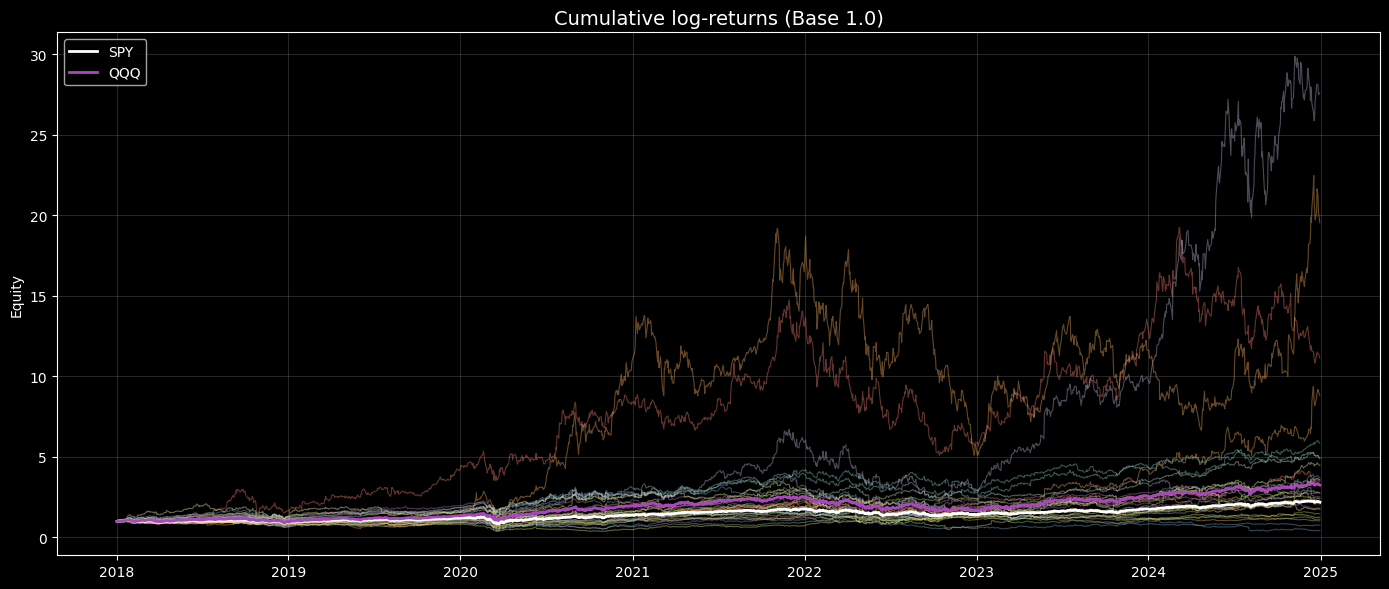

In [4]:
returns = np.log(close / close.shift(1))
cum = returns.cumsum().fillna(0).apply(np.exp)
fig, ax = plt.subplots(figsize=(14, 6))
# Plot indices thicker
if "SPY" in cum.columns:
    ax.plot(cum.index, cum["SPY"], color="white", linewidth=2, label="SPY", zorder=10)
if "QQQ" in cum.columns:
    ax.plot(cum.index, cum["QQQ"], color=COLORS["accent"], linewidth=2, label="QQQ", zorder=10)

# Plot rest
for col in cum.columns:
    if col not in ["SPY", "QQQ"]:
        ax.plot(cum.index, cum[col], alpha=0.4, linewidth=0.8)

ax.set_title("Cumulative log-returns (Base 1.0)", fontsize=14)
ax.set_ylabel("Equity")
ax.grid(alpha=0.15)
ax.legend()
plt.tight_layout()
plt.savefig("../reports/01_cumulative_returns.png", dpi=120)

## 4. Intra-day Data — Frequency Analysis for TFT Input

1m bars: 2730
1h bars: 5078


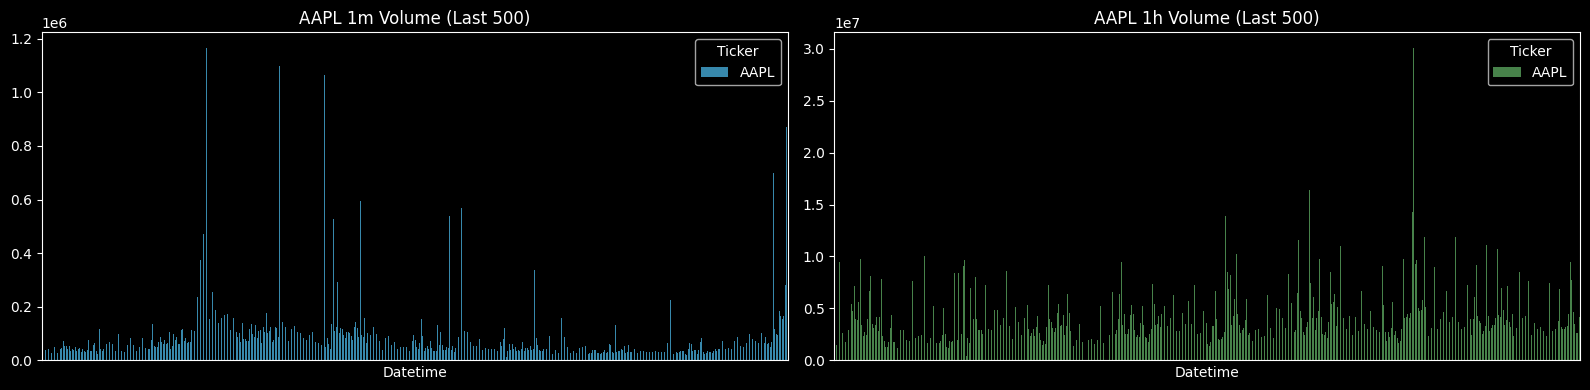

In [5]:
# The TFT Temporal Encoder consumes 1m, 1h candles.
# Download sample data for AAPL at multiple resolutions
INTRADAY_TICKER = "AAPL"
# yfinance limits: 1m (7d), 1h (730d)
intraday_1m = yf.download(INTRADAY_TICKER, period="7d", interval="1m", progress=False)
intraday_1h = yf.download(INTRADAY_TICKER, period="730d", interval="1h", progress=False)

print(f"1m bars: {len(intraday_1m)}")
print(f"1h bars: {len(intraday_1h)}")

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
intraday_1m["Volume"].tail(500).plot(kind="bar", ax=axes[0], color=COLORS["primary"], alpha=0.7)
axes[0].set_title(f"{INTRADAY_TICKER} 1m Volume (Last 500)")
axes[0].set_xticks([])

intraday_1h["Volume"].tail(500).plot(kind="bar", ax=axes[1], color=COLORS["success"], alpha=0.7)
axes[1].set_title(f"{INTRADAY_TICKER} 1h Volume (Last 500)")
axes[1].set_xticks([])
plt.tight_layout()

## 5. Return Distribution — Fat Tails & Non-Normality

In [6]:
# RL reward functions are sensitive to return distributions.
# We check kurtosis and skewness ─ heavy tails need robust normalisation.
daily_returns = returns.dropna()

print(f"{'Ticker':<8} {'Skew':>8} {'Kurt':>8} {'JB p-val':>10}")
print("-" * 40)
for col in ["SPY", "AAPL", "NVDA", "TSLA"]:
    if col in daily_returns.columns:
        s = daily_returns[col].dropna()
        jb_stat, jb_p = stats.jarque_bera(s)
        print(f"{col:<8} {s.skew():>8.3f} {s.kurtosis():>8.3f} {jb_p:>10.4f}")

Ticker       Skew     Kurt   JB p-val
----------------------------------------
SPY        -0.801   12.363     0.0000
AAPL       -0.212    5.267     0.0000
NVDA       -0.148    4.341     0.0000
TSLA       -0.059    3.616     0.0000


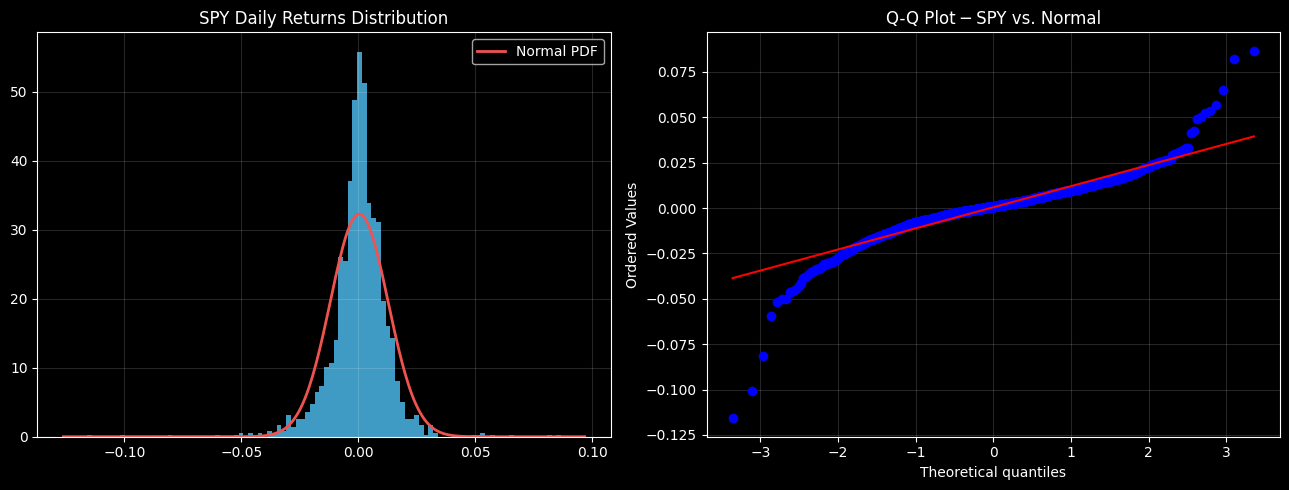

In [7]:
# Return distribution histogram for SPY
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

r = daily_returns["SPY"].dropna()
axes[0].hist(r, bins=100, color=COLORS["primary"], alpha=0.8, density=True)
xmin, xmax = axes[0].get_xlim()
xs = np.linspace(xmin, xmax, 300)
axes[0].plot(xs, stats.norm.pdf(xs, r.mean(), r.std()), color=COLORS["danger"], linewidth=2, label="Normal PDF")
axes[0].set_title("SPY Daily Returns Distribution")
axes[0].legend()
axes[0].grid(alpha=0.15)

stats.probplot(r, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot ─ SPY vs. Normal")
axes[1].grid(alpha=0.15)

plt.tight_layout()
plt.show()

## 6. Volatility Regime Detection

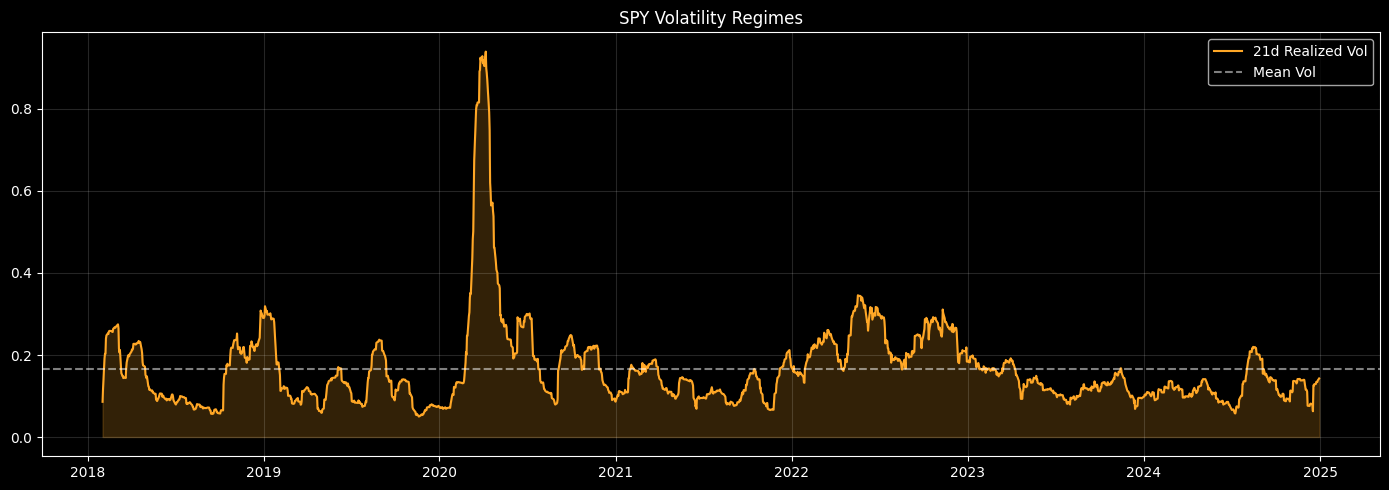

In [8]:
# Rolling 21-day realised volatility for SPY
spy_returns = daily_returns["SPY"].dropna()
realized_vol = spy_returns.rolling(window=21).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(realized_vol.index, realized_vol, color=COLORS["warning"], label="21d Realized Vol")
ax.axhline(realized_vol.mean(), color="white", linestyle="--", alpha=0.5, label="Mean Vol")
ax.set_title("SPY Volatility Regimes")
ax.fill_between(realized_vol.index, 0, realized_vol, alpha=0.2, color=COLORS["warning"])
ax.legend()
ax.grid(alpha=0.15)
plt.tight_layout()

## 7. Sector-grounded correlation matrix

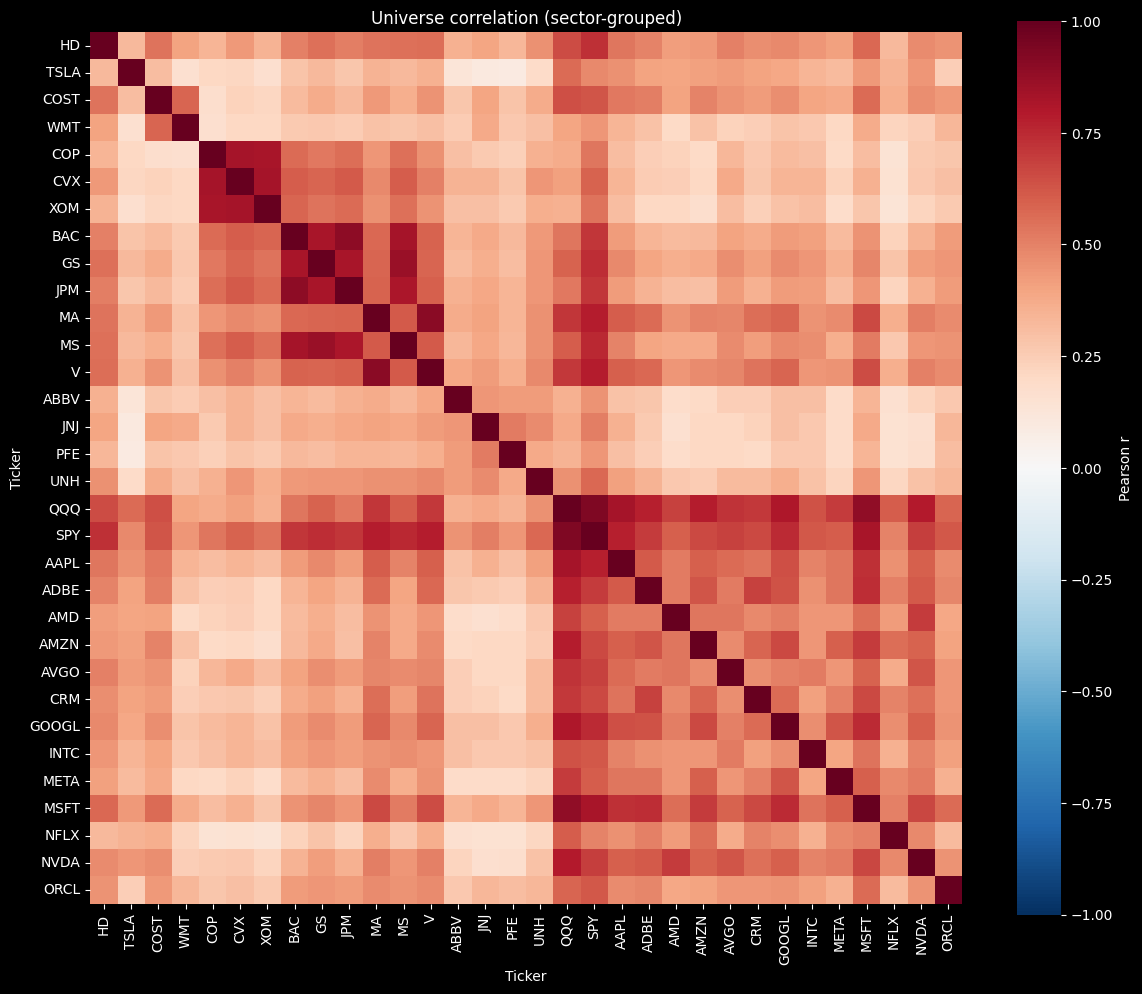

In [9]:
corr = returns.corr()
order = sorted(UNIVERSE, key=lambda t: TICKER_TO_SECTOR.get(t, "zz"))
corr = corr.reindex(index=order, columns=order)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"label": "Pearson r"},
)
ax.set_title("Universe correlation (sector-grouped)")
plt.tight_layout()
plt.savefig("../reports/01_correlation_matrix.png", dpi=120)

## 8. Intra-sector vs inter-sector correlation

In [10]:
def sector(t):
    return TICKER_TO_SECTOR.get(t, "?")


intra, inter = [], []
for i, a in enumerate(UNIVERSE):
    for b in UNIVERSE[i + 1 :]:
        if pd.isna(corr.loc[a, b]):
            continue
        (intra if sector(a) == sector(b) else inter).append(corr.loc[a, b])
print(f"Intra-sector mean r: {np.mean(intra):.3f} (n={len(intra)})")
print(f"Inter-sector mean r: {np.mean(inter):.3f} (n={len(inter)})")

Intra-sector mean r: 0.560 (n=105)
Inter-sector mean r: 0.398 (n=391)


## 9. Data Readiness Scorecard

In [11]:
checks = {
    "OHLCV daily (≥3 years)": len(close) >= 756,
    "OHLCV 1h available": len(intraday_1h) > 0,
    "Close matrix NaN < 5%": (close.isna().mean().mean() < 0.05),
    "Universe size == 32": len(UNIVERSE) == 32,
    "Intra-sector > Inter-sector": np.mean(intra) > np.mean(inter),
}

print("=" * 55)
print("  DATA READINESS SCORECARD — Lumina V3 Chimera")
print("=" * 55)
all_pass = True
for check, passed in checks.items():
    status = "✅ PASS" if passed else "❌ FAIL"
    print(f"    {status}  {check}")
    if not passed:
        all_pass = False

print("=" * 55)
print(f"  Overall: {'READY TO PROCEED ✅' if all_pass else 'FIX ISSUES ABOVE ❌'}")
print("=" * 55)

  DATA READINESS SCORECARD — Lumina V3 Chimera
    ✅ PASS  OHLCV daily (≥3 years)
    ✅ PASS  OHLCV 1h available
    ✅ PASS  Close matrix NaN < 5%
    ✅ PASS  Universe size == 32
    ✅ PASS  Intra-sector > Inter-sector
  Overall: READY TO PROCEED ✅
